In [22]:
!pip install xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
import joblib
import warnings
warnings.filterwarnings("ignore")

In [23]:
x_train=pd.read_csv("../data/X_train.csv")
x_test=pd.read_csv("../data/X_test.csv")
y_train=pd.read_csv("../data/y_train.csv").squeeze()
y_test=pd.read_csv("../data/y_test.csv").squeeze()

In [24]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
x_test.value_counts()

(179048, 21)
(24053, 21)
(179048,)
(24053,)


RevolvingUtilizationOfUnsecuredLines  age  NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  NumberOfDependents  MonthlyDebt  IncomePerDependent  TotalTimesLate  HighRiskFlag  AgeGroup_Young  AgeGroup_Middle  AgeGroup_Senior  AgeGroup_Elderly  CreditUtilCategory_Medium  CreditUtilCategory_High  CreditUtilCategory_Very High
1.000000                              22   0                                     0.000000   820.0          1                                0                        0                             0                                     0.0                 0.000000     3801.0              0               0             0               0                0                0                 0                          0                        1                               3
0.000000                              24   0                     

In [31]:

param_grid = {
    "n_estimators"    : [100, 200],
    "max_depth"       : [3, 5, 7],
    "learning_rate"   : [0.05, 0.1],
    "subsample"       : [0.8, 1.0],
}

xgb_base = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)


print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV AUC     : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters : {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV AUC     : 0.9816


In [32]:

xgb_model = grid_search.best_estimator_
y_pred_xgb = xgb_model.predict(x_test)
y_prob_xgb = xgb_model.predict_proba(x_test)[:, 1]

print("Predictions made!")

Predictions made!


In [34]:
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(classification_report(y_test, y_pred_xgb,
      target_names=["Not Default", "Default"]))
print(f"ROC-AUC Score: {auc_xgb:.4f}")

              precision    recall  f1-score   support

 Not Default       0.95      0.97      0.96     22382
     Default       0.40      0.28      0.33      1671

    accuracy                           0.92     24053
   macro avg       0.67      0.62      0.64     24053
weighted avg       0.91      0.92      0.91     24053

ROC-AUC Score: 0.8154


In [35]:

rf_model = joblib.load("../models/random_forest_model.pkl")
y_pred_rf = rf_model.predict(x_test)
y_prob_rf  = rf_model.predict_proba(x_test)[:, 1]
auc_rf     = roc_auc_score(y_test, y_prob_rf)
print("RANDOM FOREST RESULTS")

print(classification_report(y_test, y_pred_rf,
      target_names=["Not Default", "Default"]))
print(f"ROC-AUC Score: {auc_rf:.4f}")

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

 Not Default       0.96      0.92      0.94     22382
     Default       0.32      0.50      0.39      1671

    accuracy                           0.89     24053
   macro avg       0.64      0.71      0.66     24053
weighted avg       0.92      0.89      0.90     24053

ROC-AUC Score: 0.8330


In [37]:
comparison = pd.DataFrame([
    {
        "Model"    : "Random Forest",
        "ROC-AUC"  : round(auc_rf, 4),
        "Best_model"  : ""
    },
    {
        "Model"    : "XGBoost (tuned)",
        "ROC-AUC"  : round(auc_xgb, 4),
        "Best_model"  : ""
    }
])
best_idx = comparison["ROC-AUC"].idxmax()
comparison.loc[best_idx, "Best_model"] = "Winner"
print(comparison.to_string(index=False))
comparison.to_csv("../outputs/model_comparison.csv", index=False)
print("\nSaved to outputs/model_comparison.csv")

          Model  ROC-AUC Best_model
  Random Forest   0.8330     Winner
XGBoost (tuned)   0.8154           

Saved to outputs/model_comparison.csv


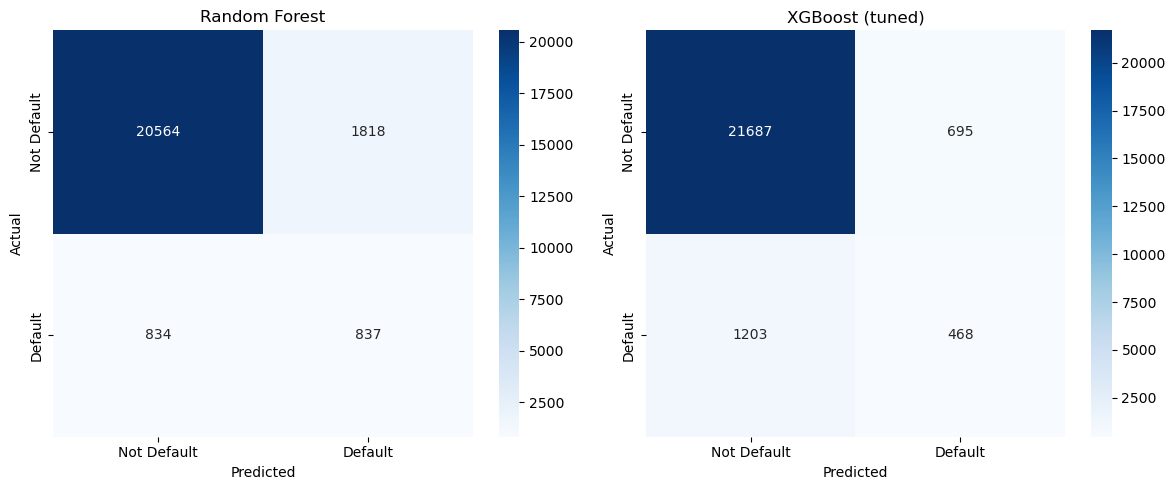

Confusion matrices saved!


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_xgb],
    ["Random Forest", "XGBoost (tuned)"]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Not Default", "Default"],
        yticklabels=["Not Default", "Default"],
        ax=ax
    )
    ax.set_title(title)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("../outputs/day7_confusion_matrices.png")
plt.show()
print("Confusion matrices saved!")

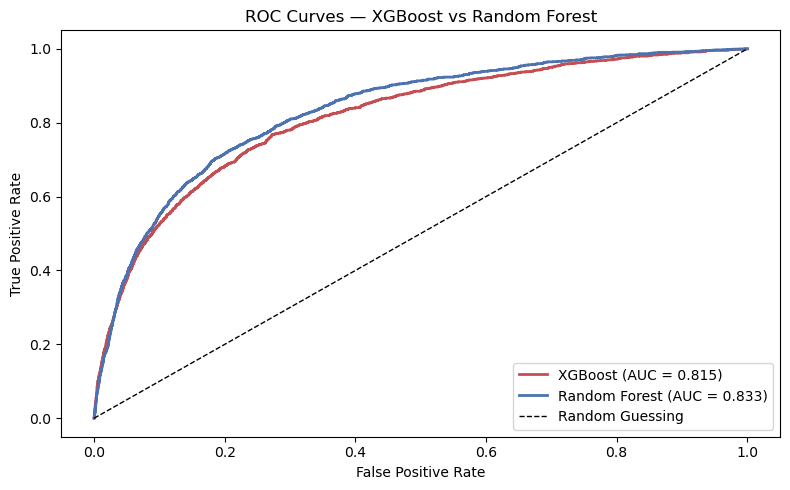

ROC comparison chart saved!


In [40]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 5))
plt.plot(fpr_xgb, tpr_xgb, color="#C44E52", lw=2,
         label=f"XGBoost (AUC = {auc_xgb:.3f})")
plt.plot(fpr_rf,  tpr_rf,  color="#4C72B0", lw=2,
         label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1,
         label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — XGBoost vs Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../outputs/day7_roc_comparison.png")
plt.show()
print("ROC comparison chart saved!")

In [41]:
joblib.dump(xgb_model, "../models/xgboost_model.pkl")
print("XGBoost model saved to models/xgboost_model.pkl")
print(f"Random Forest ROC-AUC : {auc_rf:.4f}")
print(f"XGBoost ROC-AUC       : {auc_xgb:.4f}")
print(f"Best model            : {'XGBoost' if auc_xgb > auc_rf else 'Random Forest'}")

XGBoost model saved to models/xgboost_model.pkl
Random Forest ROC-AUC : 0.8330
XGBoost ROC-AUC       : 0.8154
Best model            : Random Forest
